In [ ]:
!pip install networkx

import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
# Empty graph
G = nx.DiGraph()

# SNOMED-CT metadata
SNOMED_VERSION = "2024-01"
SNOMED_URI_BASE = "http://snomed.info/id/"

def get_snomed_uri(code):
    """Get full SNOMED-CT URI for a code"""
    return f"{SNOMED_URI_BASE}{code}"

def add_node(g, node_id, node_type, **attrs):
    """Add a node with optional SNOMED-CT coding"""
    data = {"type": node_type}
    data.update(attrs)
    # Add SNOMED URI if code is present
    if "snomed_code" in attrs:
        data["snomed_uri"] = get_snomed_uri(attrs["snomed_code"])
    g.add_node(node_id, **data)

def add_edge(g, src, dst, rel_type, **attrs):
    """Add a typed edge with optional extra attributes"""
    data = {"type": rel_type}
    data.update(attrs)
    g.add_edge(src, dst, **data)

In [ ]:
# ============================================================
# SNOMED-CT INTEGRATED KNOWLEDGE GRAPH FOR ONCOLOGY
# ============================================================

# ========== INDICATOR TYPES (SNOMED Observable Entities) ==========
add_node(G, "indtype_resting_hr", "IndicatorType", 
         name="RestingHeartRate",
         snomed_code="364075005",
         snomed_term="Heart rate")

add_node(G, "indtype_fatigue", "IndicatorType", 
         name="Fatigue",
         snomed_code="84229001",
         snomed_term="Fatigue")

add_node(G, "indtype_ecog", "IndicatorType", 
         name="ECOG",
         snomed_code="423740007",
         snomed_term="ECOG performance status")

add_node(G, "indtype_systolic_bp", "IndicatorType", 
         name="SystolicBloodPressure",
         snomed_code="271649006",
         snomed_term="Systolic blood pressure")

add_node(G, "indtype_diastolic_bp", "IndicatorType", 
         name="DiastolicBloodPressure",
         snomed_code="271650006",
         snomed_term="Diastolic blood pressure")

add_node(G, "indtype_bmi", "IndicatorType", 
         name="BMI",
         snomed_code="60621009",
         snomed_term="Body mass index")

add_node(G, "indtype_age", "IndicatorType", 
         name="Age",
         snomed_code="424144002",
         snomed_term="Current chronological age")

add_node(G, "indtype_wbc", "IndicatorType", 
         name="WhiteBloodCellCount",
         snomed_code="767002",
         snomed_term="White blood cell count")

add_node(G, "indtype_hemoglobin", "IndicatorType", 
         name="Hemoglobin",
         snomed_code="38082009",
         snomed_term="Hemoglobin")

add_node(G, "indtype_platelets", "IndicatorType", 
         name="PlateletCount",
         snomed_code="61928009",
         snomed_term="Platelet count")

add_node(G, "indtype_pain", "IndicatorType", 
         name="Pain",
         snomed_code="22253000",
         snomed_term="Pain")

add_node(G, "indtype_dyspnea", "IndicatorType", 
         name="Dyspnea",
         snomed_code="267036007",
         snomed_term="Dyspnea")

# ========== INDICATOR RANGES / THRESHOLDS ==========
# Resting heart rate
add_node(G, "range_hr_low", "IndicatorRange",
         label="HR < 60", min_value=None, max_value=60)
add_node(G, "range_hr_normal", "IndicatorRange",
         label="60 <= HR <= 90", min_value=60, max_value=90)
add_node(G, "range_hr_high", "IndicatorRange",
         label="HR > 90", min_value=90, max_value=None)
add_edge(G, "range_hr_low", "indtype_resting_hr", "FOR_INDICATOR")
add_edge(G, "range_hr_normal", "indtype_resting_hr", "FOR_INDICATOR")
add_edge(G, "range_hr_high", "indtype_resting_hr", "FOR_INDICATOR")

# Fatigue (with SNOMED qualifiers)
add_node(G, "range_fatigue_none_mild", "IndicatorRange",
         label="none/mild fatigue", severity="none_mild",
         snomed_code="84229001", snomed_qualifier="mild")
add_node(G, "range_fatigue_moderate", "IndicatorRange",
         label="moderate fatigue", severity="moderate",
         snomed_code="84229001", snomed_qualifier="moderate")
add_node(G, "range_fatigue_severe", "IndicatorRange",
         label="severe fatigue", severity="severe",
         snomed_code="84229001", snomed_qualifier="severe")
add_edge(G, "range_fatigue_none_mild", "indtype_fatigue", "FOR_INDICATOR")
add_edge(G, "range_fatigue_moderate", "indtype_fatigue", "FOR_INDICATOR")
add_edge(G, "range_fatigue_severe", "indtype_fatigue", "FOR_INDICATOR")

# ECOG (with specific SNOMED codes for each level)
add_node(G, "range_ecog_0", "IndicatorRange",
         label="ECOG 0 - Fully Active", min_value=0, max_value=0,
         snomed_code="425389002", snomed_term="ECOG grade 0")
add_node(G, "range_ecog_1", "IndicatorRange",
         label="ECOG 1 - Restricted", min_value=1, max_value=1,
         snomed_code="422512005", snomed_term="ECOG grade 1")
add_node(G, "range_ecog_0_1", "IndicatorRange",
         label="ECOG 0–1", min_value=0, max_value=1)
add_node(G, "range_ecog_2", "IndicatorRange",
         label="ECOG 2 - Ambulatory", min_value=2, max_value=2,
         snomed_code="422894000", snomed_term="ECOG grade 2")
add_node(G, "range_ecog_3", "IndicatorRange",
         label="ECOG 3 - Limited Self-care", min_value=3, max_value=3,
         snomed_code="423053003", snomed_term="ECOG grade 3")
add_node(G, "range_ecog_4", "IndicatorRange",
         label="ECOG 4 - Completely Disabled", min_value=4, max_value=4,
         snomed_code="423237006", snomed_term="ECOG grade 4")
add_node(G, "range_ecog_ge_2", "IndicatorRange",
         label="ECOG ≥ 2", min_value=2, max_value=None)
add_edge(G, "range_ecog_0", "indtype_ecog", "FOR_INDICATOR")
add_edge(G, "range_ecog_1", "indtype_ecog", "FOR_INDICATOR")
add_edge(G, "range_ecog_0_1", "indtype_ecog", "FOR_INDICATOR")
add_edge(G, "range_ecog_2", "indtype_ecog", "FOR_INDICATOR")
add_edge(G, "range_ecog_3", "indtype_ecog", "FOR_INDICATOR")
add_edge(G, "range_ecog_4", "indtype_ecog", "FOR_INDICATOR")
add_edge(G, "range_ecog_ge_2", "indtype_ecog", "FOR_INDICATOR")

# Blood pressure
add_node(G, "range_sbp_normal", "IndicatorRange",
         label="SBP 90–129 mmHg", min_value=90, max_value=129)
add_node(G, "range_sbp_elevated", "IndicatorRange",
         label="SBP 130–139 mmHg", min_value=130, max_value=139)
add_node(G, "range_sbp_high", "IndicatorRange",
         label="SBP 140–179 mmHg", min_value=140, max_value=179)
add_node(G, "range_sbp_crisis", "IndicatorRange",
         label="SBP ≥ 180 mmHg", min_value=180, max_value=None)
add_edge(G, "range_sbp_normal", "indtype_systolic_bp", "FOR_INDICATOR")
add_edge(G, "range_sbp_elevated", "indtype_systolic_bp", "FOR_INDICATOR")
add_edge(G, "range_sbp_high", "indtype_systolic_bp", "FOR_INDICATOR")
add_edge(G, "range_sbp_crisis", "indtype_systolic_bp", "FOR_INDICATOR")

# BMI
add_node(G, "range_bmi_underweight", "IndicatorRange",
         label="BMI < 18.5", min_value=None, max_value=18.4)
add_node(G, "range_bmi_normal", "IndicatorRange",
         label="BMI 18.5–24.9", min_value=18.5, max_value=24.9)
add_node(G, "range_bmi_overweight", "IndicatorRange",
         label="BMI 25–29.9", min_value=25.0, max_value=29.9)
add_node(G, "range_bmi_obese", "IndicatorRange",
         label="BMI ≥ 30", min_value=30.0, max_value=None,
         snomed_code="414916001", snomed_term="Obesity")
add_edge(G, "range_bmi_underweight", "indtype_bmi", "FOR_INDICATOR")
add_edge(G, "range_bmi_normal", "indtype_bmi", "FOR_INDICATOR")
add_edge(G, "range_bmi_overweight", "indtype_bmi", "FOR_INDICATOR")
add_edge(G, "range_bmi_obese", "indtype_bmi", "FOR_INDICATOR")

# White blood cell count
add_node(G, "range_wbc_very_low", "IndicatorRange",
         label="WBC < 3.0 (Neutropenia)", min_value=None, max_value=2.9,
         snomed_code="165517008", snomed_term="Neutropenia")
add_node(G, "range_wbc_low", "IndicatorRange",
         label="WBC 3.0–3.9", min_value=3.0, max_value=3.9)
add_node(G, "range_wbc_normal", "IndicatorRange",
         label="WBC 4.0–11.0", min_value=4.0, max_value=11.0)
add_edge(G, "range_wbc_very_low", "indtype_wbc", "FOR_INDICATOR")
add_edge(G, "range_wbc_low", "indtype_wbc", "FOR_INDICATOR")
add_edge(G, "range_wbc_normal", "indtype_wbc", "FOR_INDICATOR")

# Hemoglobin
add_node(G, "range_hgb_severe_anemia", "IndicatorRange",
         label="Hgb < 8 g/dL (Severe)", min_value=None, max_value=7.9,
         snomed_code="271737000", snomed_term="Anemia")
add_node(G, "range_hgb_moderate_anemia", "IndicatorRange",
         label="Hgb 8–10 g/dL (Moderate)", min_value=8.0, max_value=9.9,
         snomed_code="271737000", snomed_term="Anemia")
add_node(G, "range_hgb_mild_anemia", "IndicatorRange",
         label="Hgb 10–12 g/dL (Mild)", min_value=10.0, max_value=11.9)
add_node(G, "range_hgb_normal", "IndicatorRange",
         label="Hgb ≥ 12 g/dL", min_value=12.0, max_value=None)
add_edge(G, "range_hgb_severe_anemia", "indtype_hemoglobin", "FOR_INDICATOR")
add_edge(G, "range_hgb_moderate_anemia", "indtype_hemoglobin", "FOR_INDICATOR")
add_edge(G, "range_hgb_mild_anemia", "indtype_hemoglobin", "FOR_INDICATOR")
add_edge(G, "range_hgb_normal", "indtype_hemoglobin", "FOR_INDICATOR")

# Platelets
add_node(G, "range_platelets_low", "IndicatorRange",
         label="Platelets < 100k (Thrombocytopenia)", min_value=None, max_value=99,
         snomed_code="302215000", snomed_term="Thrombocytopenic disorder")
add_node(G, "range_platelets_normal", "IndicatorRange",
         label="Platelets 100k–400k", min_value=100, max_value=400)
add_edge(G, "range_platelets_low", "indtype_platelets", "FOR_INDICATOR")
add_edge(G, "range_platelets_normal", "indtype_platelets", "FOR_INDICATOR")

# Pain levels
add_node(G, "range_pain_none_mild", "IndicatorRange",
         label="No/Mild Pain (0-3)", min_value=0, max_value=3,
         snomed_code="22253000", snomed_qualifier="mild")
add_node(G, "range_pain_moderate", "IndicatorRange",
         label="Moderate Pain (4-6)", min_value=4, max_value=6,
         snomed_code="22253000", snomed_qualifier="moderate")
add_node(G, "range_pain_severe", "IndicatorRange",
         label="Severe Pain (7-10)", min_value=7, max_value=10,
         snomed_code="22253000", snomed_qualifier="severe")
add_edge(G, "range_pain_none_mild", "indtype_pain", "FOR_INDICATOR")
add_edge(G, "range_pain_moderate", "indtype_pain", "FOR_INDICATOR")
add_edge(G, "range_pain_severe", "indtype_pain", "FOR_INDICATOR")

# Dyspnea levels
add_node(G, "range_dyspnea_none_mild", "IndicatorRange",
         label="No/Mild Dyspnea", severity="mild",
         snomed_code="267036007", snomed_qualifier="mild")
add_node(G, "range_dyspnea_moderate", "IndicatorRange",
         label="Moderate Dyspnea", severity="moderate",
         snomed_code="267036007", snomed_qualifier="moderate")
add_node(G, "range_dyspnea_severe", "IndicatorRange",
         label="Severe Dyspnea", severity="severe",
         snomed_code="267036007", snomed_qualifier="severe")
add_edge(G, "range_dyspnea_none_mild", "indtype_dyspnea", "FOR_INDICATOR")
add_edge(G, "range_dyspnea_moderate", "indtype_dyspnea", "FOR_INDICATOR")
add_edge(G, "range_dyspnea_severe", "indtype_dyspnea", "FOR_INDICATOR")

# Age ranges
add_node(G, "range_age_18_40", "IndicatorRange",
         label="Age 18–40", min_value=18, max_value=40)
add_node(G, "range_age_41_65", "IndicatorRange",
         label="Age 41–65", min_value=41, max_value=65)
add_node(G, "range_age_ge_65", "IndicatorRange",
         label="Age ≥ 65", min_value=66, max_value=None)
add_edge(G, "range_age_18_40", "indtype_age", "FOR_INDICATOR")
add_edge(G, "range_age_41_65", "indtype_age", "FOR_INDICATOR")
add_edge(G, "range_age_ge_65", "indtype_age", "FOR_INDICATOR")

# ========== DISEASES (SNOMED Clinical Finding/Disorder) ==========
add_node(G, "disease_breast_cancer", "Disease",
         name="BreastCancer",
         snomed_code="254837009",
         snomed_term="Malignant neoplasm of breast",
         icd10="C50")

add_node(G, "disease_lung_cancer", "Disease",
         name="LungCancer",
         snomed_code="254637007",
         snomed_term="Malignant neoplasm of lung",
         icd10="C34")

add_node(G, "disease_colorectal_cancer", "Disease",
         name="ColorectalCancer",
         snomed_code="363406005",
         snomed_term="Malignant tumor of colon",
         icd10="C18-C20")

add_node(G, "disease_prostate_cancer", "Disease",
         name="ProstateCancer",
         snomed_code="399068003",
         snomed_term="Malignant tumor of prostate",
         icd10="C61")

add_node(G, "disease_lymphoma", "Disease",
         name="Lymphoma",
         snomed_code="118600007",
         snomed_term="Malignant lymphoma",
         icd10="C81-C85")

add_node(G, "disease_leukemia", "Disease",
         name="Leukemia",
         snomed_code="93143009",
         snomed_term="Leukemia",
         icd10="C91-C95")

add_node(G, "disease_ovarian_cancer", "Disease",
         name="OvarianCancer",
         snomed_code="363443007",
         snomed_term="Malignant tumor of ovary",
         icd10="C56")

add_node(G, "disease_pancreatic_cancer", "Disease",
         name="PancreaticCancer",
         snomed_code="363418001",
         snomed_term="Malignant tumor of pancreas",
         icd10="C25")

add_node(G, "disease_gastric_cancer", "Disease",
         name="GastricCancer",
         snomed_code="363349007",
         snomed_term="Malignant tumor of stomach",
         icd10="C16")

add_node(G, "disease_melanoma", "Disease",
         name="Melanoma",
         snomed_code="372244006",
         snomed_term="Malignant melanoma",
         icd10="C43")

# ========== COMORBIDITIES ==========
add_node(G, "disease_hypertension", "Disease",
         name="Hypertension",
         snomed_code="38341003",
         snomed_term="Hypertensive disorder",
         icd10="I10")

add_node(G, "disease_type2_diabetes", "Disease",
         name="Type2Diabetes",
         snomed_code="44054006",
         snomed_term="Type 2 diabetes mellitus",
         icd10="E11")

add_node(G, "disease_heart_failure", "Disease",
         name="HeartFailure",
         snomed_code="84114007",
         snomed_term="Heart failure",
         icd10="I50")

add_node(G, "disease_copd", "Disease",
         name="COPD",
         snomed_code="13645005",
         snomed_term="Chronic obstructive lung disease",
         icd10="J44")

add_node(G, "disease_osteoporosis", "Disease",
         name="Osteoporosis",
         snomed_code="64859006",
         snomed_term="Osteoporosis",
         icd10="M81")

add_node(G, "disease_osteoarthritis", "Disease",
         name="Osteoarthritis",
         snomed_code="396275006",
         snomed_term="Osteoarthritis",
         icd10="M15-M19")

add_node(G, "disease_ckd", "Disease",
         name="ChronicKidneyDisease",
         snomed_code="709044004",
         snomed_term="Chronic kidney disease",
         icd10="N18")

# ========== CANCER STAGES ==========
add_node(G, "stage_i", "CancerStage",
         label="Stage I",
         snomed_code="258215001",
         snomed_term="Stage I")

add_node(G, "stage_ii", "CancerStage",
         label="Stage II",
         snomed_code="258219007",
         snomed_term="Stage II")

add_node(G, "stage_iii", "CancerStage",
         label="Stage III",
         snomed_code="258224005",
         snomed_term="Stage III")

add_node(G, "stage_iv", "CancerStage",
         label="Stage IV",
         snomed_code="258228008",
         snomed_term="Stage IV")

add_node(G, "remission", "CancerStage",
         label="In Remission",
         snomed_code="277022003",
         snomed_term="Remission phase")

add_node(G, "metastatic", "CancerStage",
         label="Metastatic Disease",
         snomed_code="405843009",
         snomed_term="Secondary malignant neoplastic disease")

# ========== TREATMENTS ==========
add_node(G, "treatment_chemotherapy", "Treatment",
         label="Chemotherapy",
         snomed_code="367336001",
         snomed_term="Chemotherapy")

add_node(G, "treatment_radiotherapy", "Treatment",
         label="Radiotherapy",
         snomed_code="108290001",
         snomed_term="Radiation oncology")

add_node(G, "treatment_immunotherapy", "Treatment",
         label="Immunotherapy",
         snomed_code="76334006",
         snomed_term="Immunotherapy")

add_node(G, "treatment_hormone_therapy", "Treatment",
         label="Hormone Therapy",
         snomed_code="169413002",
         snomed_term="Hormone therapy")

add_node(G, "treatment_surgery", "Treatment",
         label="Surgery",
         snomed_code="387713003",
         snomed_term="Surgical procedure")

add_node(G, "treatment_palliative", "Treatment",
         label="Palliative Care",
         snomed_code="103735009",
         snomed_term="Palliative care")

# ========== SIDE EFFECTS ==========
add_node(G, "sideeffect_neuropathy", "SideEffect",
         label="Peripheral Neuropathy",
         snomed_code="386033004",
         snomed_term="Neuropathy")

add_node(G, "sideeffect_lymphedema", "SideEffect",
         label="Lymphedema",
         snomed_code="234097001",
         snomed_term="Lymphedema")

add_node(G, "sideeffect_cardiotoxicity", "SideEffect",
         label="Cardiotoxicity",
         snomed_code="698247007",
         snomed_term="Cardiac toxicity")

add_node(G, "sideeffect_nausea", "SideEffect",
         label="Nausea",
         snomed_code="422587007",
         snomed_term="Nausea")

add_node(G, "sideeffect_mucositis", "SideEffect",
         label="Mucositis",
         snomed_code="26580005",
         snomed_term="Mucositis")

add_node(G, "sideeffect_bone_pain", "SideEffect",
         label="Bone Pain",
         snomed_code="12584003",
         snomed_term="Bone pain")

# ========== ACTIVITIES (SNOMED Procedures) ==========
add_node(G, "act_walking_light", "Activity",
         label="Light Walking 15-20 min",
         intensity="light", met=2.5,
         snomed_code="129006008",
         snomed_term="Walking")

add_node(G, "act_walking_moderate", "Activity",
         label="Moderate Walking 30 min",
         intensity="moderate", met=3.5,
         snomed_code="129006008",
         snomed_term="Walking")

add_node(G, "act_nordic_walking", "Activity",
         label="Nordic Walking 30 min",
         intensity="moderate", met=4.5,
         snomed_code="129006008",
         snomed_term="Walking")

add_node(G, "act_yoga_gentle", "Activity",
         label="Gentle Yoga 20-30 min",
         intensity="light", met=2.5,
         snomed_code="229065009",
         snomed_term="Exercise therapy")

add_node(G, "act_yoga_chair", "Activity",
         label="Chair Yoga 15-20 min",
         intensity="very_light", met=2.0,
         snomed_code="229065009",
         snomed_term="Exercise therapy")

add_node(G, "act_tai_chi", "Activity",
         label="Tai Chi 20-30 min",
         intensity="light", met=2.5,
         snomed_code="229072005",
         snomed_term="Tai Chi")

add_node(G, "act_aquagym", "Activity",
         label="Aquagym 30 min",
         intensity="moderate", met=4.0,
         snomed_code="229071003",
         snomed_term="Aquatic physiotherapy")

add_node(G, "act_swimming_light", "Activity",
         label="Light Swimming 20 min",
         intensity="light", met=3.0,
         snomed_code="20461001",
         snomed_term="Swimming")

add_node(G, "act_breathing_exercises", "Activity",
         label="Breathing Exercises 15 min",
         intensity="very_light", met=1.5,
         snomed_code="304549008",
         snomed_term="Breathing exercise")

add_node(G, "act_stretching", "Activity",
         label="Stretching 15-20 min",
         intensity="very_light", met=2.0,
         snomed_code="225317005",
         snomed_term="Stretching")

add_node(G, "act_cycling_stationary", "Activity",
         label="Stationary Cycling 20 min",
         intensity="moderate", met=4.0,
         snomed_code="70665002",
         snomed_term="Bicycle exercise")

add_node(G, "act_strength_light", "Activity",
         label="Light Strength Training 15 min",
         intensity="light", met=3.0,
         snomed_code="266694003",
         snomed_term="Resistance training")

add_node(G, "act_resistance_bands", "Activity",
         label="Resistance Band Exercise 15 min",
         intensity="light", met=2.5,
         snomed_code="266694003",
         snomed_term="Resistance training")

add_node(G, "act_balance_training", "Activity",
         label="Balance Training 15 min",
         intensity="light", met=2.0,
         snomed_code="710841007",
         snomed_term="Balance training")

add_node(G, "act_relaxation", "Activity",
         label="Guided Relaxation 15 min",
         intensity="very_light", met=1.0,
         snomed_code="228557008",
         snomed_term="Relaxation therapy")

add_node(G, "act_pilates_gentle", "Activity",
         label="Gentle Pilates 20 min",
         intensity="light", met=2.5,
         snomed_code="229065009",
         snomed_term="Exercise therapy")

add_node(G, "act_aerobic_light", "Activity",
         label="Light Aerobic Exercise 20 min",
         intensity="light", met=3.0,
         snomed_code="229070002",
         snomed_term="Aerobic exercises")

# ========== CONTRAINDICATION REASONS ==========
add_node(G, "contra_bleeding_risk", "ContraindicationReason",
         label="Risk of Bleeding",
         snomed_code="131148009",
         snomed_term="Bleeding risk")

add_node(G, "contra_fracture_risk", "ContraindicationReason",
         label="Risk of Fracture",
         snomed_code="473128000",
         snomed_term="Risk of fracture")

add_node(G, "contra_infection_risk", "ContraindicationReason",
         label="Risk of Infection",
         snomed_code="409822003",
         snomed_term="Infection risk")

add_node(G, "contra_cardiac_risk", "ContraindicationReason",
         label="Cardiac Risk",
         snomed_code="395098000",
         snomed_term="Risk of cardiac event")

add_node(G, "contra_fall_risk", "ContraindicationReason",
         label="Risk of Falling",
         snomed_code="129839007",
         snomed_term="At risk for falls")

# ========== CONDITION PROFILES ==========
# Profile 1: Breast cancer + ECOG 0–1 + no severe fatigue
add_node(G, "profile_bc_ecog01_no_severe_fatigue", "ConditionProfile",
         label="Breast cancer, ECOG 0–1, no severe fatigue")
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "disease_breast_cancer", "HAS_DISEASE")
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "range_ecog_0_1", "HAS_INDICATOR_CONSTRAINT")
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "range_fatigue_none_mild", "HAS_INDICATOR_CONSTRAINT")

# Profile 2: Cancer + severe fatigue
add_node(G, "profile_cancer_severe_fatigue", "ConditionProfile",
         label="Cancer with severe fatigue")
add_edge(G, "profile_cancer_severe_fatigue", "range_fatigue_severe", "HAS_INDICATOR_CONSTRAINT")

# Profile 3: Cancer + moderate fatigue
add_node(G, "profile_cancer_moderate_fatigue", "ConditionProfile",
         label="Cancer with moderate fatigue")
add_edge(G, "profile_cancer_moderate_fatigue", "range_fatigue_moderate", "HAS_INDICATOR_CONSTRAINT")

# Profile 4: Hypertension + high BP
add_node(G, "profile_htn_high_bp", "ConditionProfile",
         label="Hypertension with high BP")
add_edge(G, "profile_htn_high_bp", "disease_hypertension", "HAS_DISEASE")
add_edge(G, "profile_htn_high_bp", "range_sbp_high", "HAS_INDICATOR_CONSTRAINT")

# Profile 5: Immunocompromised (low WBC)
add_node(G, "profile_immunocompromised", "ConditionProfile",
         label="Immunocompromised (low WBC)")
add_edge(G, "profile_immunocompromised", "range_wbc_very_low", "HAS_INDICATOR_CONSTRAINT")

# Profile 6: Severe anemia
add_node(G, "profile_severe_anemia", "ConditionProfile",
         label="Severe anemia")
add_edge(G, "profile_severe_anemia", "range_hgb_severe_anemia", "HAS_INDICATOR_CONSTRAINT")

# Profile 7: Neuropathy
add_node(G, "profile_neuropathy", "ConditionProfile",
         label="Peripheral neuropathy")
add_edge(G, "profile_neuropathy", "sideeffect_neuropathy", "HAS_SIDE_EFFECT")

# Profile 8: Lymphedema
add_node(G, "profile_lymphedema", "ConditionProfile",
         label="Lymphedema")
add_edge(G, "profile_lymphedema", "sideeffect_lymphedema", "HAS_SIDE_EFFECT")

# Profile 9: Bone metastases
add_node(G, "profile_bone_mets", "ConditionProfile",
         label="Bone metastases")
add_edge(G, "profile_bone_mets", "metastatic", "HAS_STAGE")
add_edge(G, "profile_bone_mets", "sideeffect_bone_pain", "HAS_SIDE_EFFECT")

# Profile 10: Active chemotherapy
add_node(G, "profile_active_chemo", "ConditionProfile",
         label="On active chemotherapy")
add_edge(G, "profile_active_chemo", "treatment_chemotherapy", "HAS_TREATMENT")

# Profile 11: Low platelets
add_node(G, "profile_low_platelets", "ConditionProfile",
         label="Thrombocytopenia")
add_edge(G, "profile_low_platelets", "range_platelets_low", "HAS_INDICATOR_CONSTRAINT")

# Profile 12: ECOG ≥ 3 (poor functional status)
add_node(G, "profile_ecog_ge_3", "ConditionProfile",
         label="ECOG ≥ 3 - Limited function")
add_edge(G, "profile_ecog_ge_3", "range_ecog_3", "HAS_INDICATOR_CONSTRAINT")

# Profile 13: Heart failure
add_node(G, "profile_heart_failure", "ConditionProfile",
         label="Heart failure")
add_edge(G, "profile_heart_failure", "disease_heart_failure", "HAS_DISEASE")

# Profile 14: COPD with dyspnea
add_node(G, "profile_copd_dyspnea", "ConditionProfile",
         label="COPD with dyspnea")
add_edge(G, "profile_copd_dyspnea", "disease_copd", "HAS_DISEASE")
add_edge(G, "profile_copd_dyspnea", "range_dyspnea_moderate", "HAS_INDICATOR_CONSTRAINT")

# ========== GUIDELINE STATEMENTS ==========
add_node(G, "guideline_acsm_walking", "GuidelineStatement",
         source="ACSM Guidelines 2019",
         text="For cancer survivors with ECOG 0-1, 30 min moderate walking is recommended.",
         snomed_activity="129006008")

add_node(G, "guideline_nccn_fatigue", "GuidelineStatement",
         source="NCCN Fatigue Guidelines",
         text="For severe fatigue, prioritize rest with gentle breathing exercises when tolerated.",
         snomed_condition="84229001")

add_node(G, "guideline_esmo_lymphedema", "GuidelineStatement",
         source="ESMO Guidelines",
         text="Aquatic exercises are particularly beneficial for patients with lymphedema.",
         snomed_condition="234097001")

add_node(G, "guideline_cdc_neutropenia", "GuidelineStatement",
         source="CDC Immunocompromised Guidelines",
         text="Patients with neutropenia should avoid public pools and crowded gyms.",
         snomed_condition="165517008")

add_node(G, "guideline_asco_bone_mets", "GuidelineStatement",
         source="ASCO Bone Metastases Guidelines",
         text="Avoid high-impact activities and heavy resistance training with bone metastases.",
         snomed_condition="405843009")

add_node(G, "guideline_neuropathy_balance", "GuidelineStatement",
         source="ONS Neuropathy Guidelines",
         text="Balance training is recommended for neuropathy patients to reduce fall risk.",
         snomed_condition="386033004")

# ========== CLINICAL RULES (RECOMMENDS / CONTRAINDICATES) ==========

# Recommendations for good functional status
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "act_walking_moderate", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "act_yoga_gentle", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "act_aquagym", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "act_cycling_stationary", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "act_nordic_walking", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_bc_ecog01_no_severe_fatigue", "act_tai_chi", "RECOMMENDS_ACTIVITY")

# Recommendations for moderate fatigue
add_edge(G, "profile_cancer_moderate_fatigue", "act_walking_light", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_cancer_moderate_fatigue", "act_yoga_chair", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_cancer_moderate_fatigue", "act_breathing_exercises", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_cancer_moderate_fatigue", "act_stretching", "RECOMMENDS_ACTIVITY")

# Recommendations for severe fatigue
add_edge(G, "profile_cancer_severe_fatigue", "act_breathing_exercises", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_cancer_severe_fatigue", "act_relaxation", "RECOMMENDS_ACTIVITY")

# Recommendations for hypertension
add_edge(G, "profile_htn_high_bp", "act_walking_light", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_htn_high_bp", "act_tai_chi", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_htn_high_bp", "act_yoga_gentle", "RECOMMENDS_ACTIVITY")

# Recommendations for immunocompromised
add_edge(G, "profile_immunocompromised", "act_walking_light", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_immunocompromised", "act_yoga_chair", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_immunocompromised", "act_breathing_exercises", "RECOMMENDS_ACTIVITY")

# Recommendations for neuropathy
add_edge(G, "profile_neuropathy", "act_balance_training", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_neuropathy", "act_yoga_chair", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_neuropathy", "act_stretching", "RECOMMENDS_ACTIVITY")

# Recommendations for lymphedema
add_edge(G, "profile_lymphedema", "act_aquagym", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_lymphedema", "act_yoga_gentle", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_lymphedema", "act_walking_light", "RECOMMENDS_ACTIVITY")

# Recommendations for COPD
add_edge(G, "profile_copd_dyspnea", "act_breathing_exercises", "RECOMMENDS_ACTIVITY")
add_edge(G, "profile_copd_dyspnea", "act_walking_light", "RECOMMENDS_ACTIVITY")

# ========== CONTRAINDICATIONS ==========

# Severe fatigue contraindications
add_edge(G, "profile_cancer_severe_fatigue", "act_walking_moderate", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")
add_edge(G, "profile_cancer_severe_fatigue", "act_cycling_stationary", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")
add_edge(G, "profile_cancer_severe_fatigue", "act_aquagym", "CONTRAINDICATES_ACTIVITY",
         reason="contra_fall_risk")
add_edge(G, "profile_cancer_severe_fatigue", "act_nordic_walking", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")

# Hypertension contraindications
add_edge(G, "profile_htn_high_bp", "act_cycling_stationary", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")
add_edge(G, "profile_htn_high_bp", "act_strength_light", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")

# Immunocompromised contraindications
add_edge(G, "profile_immunocompromised", "act_aquagym", "CONTRAINDICATES_ACTIVITY",
         reason="contra_infection_risk")
add_edge(G, "profile_immunocompromised", "act_swimming_light", "CONTRAINDICATES_ACTIVITY",
         reason="contra_infection_risk")

# Severe anemia contraindications
add_edge(G, "profile_severe_anemia", "act_walking_moderate", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")
add_edge(G, "profile_severe_anemia", "act_cycling_stationary", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")
add_edge(G, "profile_severe_anemia", "act_aquagym", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")

# Low platelets contraindications
add_edge(G, "profile_low_platelets", "act_strength_light", "CONTRAINDICATES_ACTIVITY",
         reason="contra_bleeding_risk")
add_edge(G, "profile_low_platelets", "act_cycling_stationary", "CONTRAINDICATES_ACTIVITY",
         reason="contra_bleeding_risk")

# Neuropathy contraindications
add_edge(G, "profile_neuropathy", "act_cycling_stationary", "CONTRAINDICATES_ACTIVITY",
         reason="contra_fall_risk")
add_edge(G, "profile_neuropathy", "act_nordic_walking", "CONTRAINDICATES_ACTIVITY",
         reason="contra_fall_risk")

# Bone metastases contraindications
add_edge(G, "profile_bone_mets", "act_strength_light", "CONTRAINDICATES_ACTIVITY",
         reason="contra_fracture_risk")
add_edge(G, "profile_bone_mets", "act_nordic_walking", "CONTRAINDICATES_ACTIVITY",
         reason="contra_fracture_risk")

# Poor functional status contraindications
add_edge(G, "profile_ecog_ge_3", "act_walking_moderate", "CONTRAINDICATES_ACTIVITY",
         reason="contra_fall_risk")
add_edge(G, "profile_ecog_ge_3", "act_cycling_stationary", "CONTRAINDICATES_ACTIVITY",
         reason="contra_fall_risk")
add_edge(G, "profile_ecog_ge_3", "act_aquagym", "CONTRAINDICATES_ACTIVITY",
         reason="contra_fall_risk")

# Heart failure contraindications
add_edge(G, "profile_heart_failure", "act_cycling_stationary", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")
add_edge(G, "profile_heart_failure", "act_nordic_walking", "CONTRAINDICATES_ACTIVITY",
         reason="contra_cardiac_risk")

print(f"Knowledge Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"SNOMED-CT version: {SNOMED_VERSION}")

In [ ]:
import networkx as nx
import numpy as np

# ---------- 1. Utility to find nodes by attributes ----------

def get_node_by_attr(G, node_type, **attrs):
    """
    Find the first node of given type with matching attributes.
    """
    for n, data in G.nodes(data=True):
        if data.get("type") != node_type:
            continue
        ok = True
        for k, v in attrs.items():
            if data.get(k) != v:
                ok = False
                break
        if ok:
            return n
    return None

# Precompute some useful node IDs (assumes your KG structure from earlier)
INDTYPE_RESTING_HR = get_node_by_attr(G, "IndicatorType", name="RestingHeartRate")
INDTYPE_FATIGUE    = get_node_by_attr(G, "IndicatorType", name="Fatigue")
INDTYPE_ECOG       = get_node_by_attr(G, "IndicatorType", name="ECOG")

DISEASE_BC  = get_node_by_attr(G, "Disease", name="BreastCancer")
DISEASE_HTN = get_node_by_attr(G, "Disease", name="Hypertension")

ACT_MOD_WALK = get_node_by_attr(G, "Activity", label="30 min moderate walking")
ACT_HI_IMPACT = get_node_by_attr(G, "Activity", label="30 min high-impact aerobics")

print("INDTYPE_RESTING_HR:", INDTYPE_RESTING_HR)
print("INDTYPE_FATIGUE   :", INDTYPE_FATIGUE)
print("INDTYPE_ECOG      :", INDTYPE_ECOG)
print("DISEASE_BC        :", DISEASE_BC)
print("DISEASE_HTN       :", DISEASE_HTN)
print("ACT_MOD_WALK      :", ACT_MOD_WALK)
print("ACT_HI_IMPACT     :", ACT_HI_IMPACT)

# ---------- 2. Mapping raw values to IndicatorRange nodes ----------

def map_numeric_to_range(G, indicator_type_id, value):
    """
    For a numeric indicator (HR, ECOG), find the IndicatorRange node that:
    - has a FOR_INDICATOR edge -> indicator_type_id
    - whose [min_value, max_value] interval contains 'value'
    """
    for n, data in G.nodes(data=True):
        if data.get("type") != "IndicatorRange":
            continue

        # Check it belongs to the right indicator
        belongs = False
        for _, tgt, edata in G.out_edges(n, data=True):
            if edata.get("type") == "FOR_INDICATOR" and tgt == indicator_type_id:
                belongs = True
                break
        if not belongs:
            continue

        min_v = data.get("min_value")
        max_v = data.get("max_value")

        if (min_v is None or value >= min_v) and (max_v is None or value <= max_v):
            return n

    return None

def map_fatigue_to_range(G, severity_str):
    """
    For categorical fatigue: use the 'severity' attribute on IndicatorRange nodes.
    severity_str in {"none_mild", "moderate", "severe"}.
    """
    for n, data in G.nodes(data=True):
        if data.get("type") != "IndicatorRange":
            continue
        if data.get("severity") != severity_str:
            continue

        # Ensure this range is for the Fatigue indicator
        for _, tgt, edata in G.out_edges(n, data=True):
            if edata.get("type") == "FOR_INDICATOR" and tgt == INDTYPE_FATIGUE:
                return n

    return None

def map_patient_to_ranges(G, patient):
    """
    patient = {
        "disease": "BreastCancer" or "Hypertension",
        "resting_hr": int,
        "ecog": int,
        "fatigue": "none_mild" | "moderate" | "severe"
    }
    Returns dict with node IDs for disease, hr_range, ecog_range, fatigue_range.
    """
    if patient["disease"] == "BreastCancer":
        disease_node = DISEASE_BC
    elif patient["disease"] == "Hypertension":
        disease_node = DISEASE_HTN
    else:
        disease_node = None

    hr_range_node    = map_numeric_to_range(G, INDTYPE_RESTING_HR, patient["resting_hr"])
    ecog_range_node  = map_numeric_to_range(G, INDTYPE_ECOG, patient["ecog"])
    fatigue_range_node = map_fatigue_to_range(G, patient["fatigue"])

    return {
        "disease_node":      disease_node,
        "hr_range_node":     hr_range_node,
        "ecog_range_node":   ecog_range_node,
        "fatigue_range_node": fatigue_range_node,
    }

# ---------- 3. Profile matching and activity extraction ----------

def find_matching_profiles(G, mapped):
    """
    Given mapped ranges + disease, return ConditionProfile nodes whose
    HAS_DISEASE and HAS_INDICATOR_CONSTRAINT edges are satisfied.
    """
    disease_node = mapped["disease_node"]
    hr_range     = mapped["hr_range_node"]
    ecog_range   = mapped["ecog_range_node"]
    fatigue_range = mapped["fatigue_range_node"]

    patient_ranges = {r for r in [hr_range, ecog_range, fatigue_range] if r is not None}

    matching_profiles = []

    for n, data in G.nodes(data=True):
        if data.get("type") != "ConditionProfile":
            continue

        diseases = set()
        ranges   = set()

        for _, tgt, edata in G.out_edges(n, data=True):
            if edata.get("type") == "HAS_DISEASE":
                diseases.add(tgt)
            elif edata.get("type") == "HAS_INDICATOR_CONSTRAINT":
                ranges.add(tgt)

        # Disease must match
        if disease_node not in diseases:
            continue

        # All constraints of the profile must be in patient's ranges
        if not ranges.issubset(patient_ranges):
            continue

        matching_profiles.append(n)

    return matching_profiles

def get_activities_for_profiles(G, profiles):
    """
    From given ConditionProfile nodes, collect recommended and contraindicated activities.
    """
    recommended    = set()
    contraindicated = set()

    for p in profiles:
        for _, tgt, edata in G.out_edges(p, data=True):
            if edata.get("type") == "RECOMMENDS_ACTIVITY":
                recommended.add(tgt)
            elif edata.get("type") == "CONTRAINDICATES_ACTIVITY":
                contraindicated.add(tgt)

    safe = recommended - contraindicated
    return safe, contraindicated, recommended

def recommend_from_kg(G, patient):
    """
    Main entry point: given patient dict, use KG to output safe and contraindicated activities.
    """
    mapped   = map_patient_to_ranges(G, patient)
    profiles = find_matching_profiles(G, mapped)
    safe, contraindicated, recommended = get_activities_for_profiles(G, profiles)

    return {
        "profiles":               profiles,
        "safe_activities":        list(safe),
        "contraindicated_activities": list(contraindicated),
        "recommended_activities": list(recommended),
    }

# ---------- 4. Test on the original example patient (pure KG reasoning) ----------

patient_example = {
    "disease":    "BreastCancer",
    "resting_hr": 50,          # HR < 60 → low
    "ecog":       1,           # ECOG 0–1
    "fatigue":    "none_mild", # none/mild fatigue
}

res = recommend_from_kg(G, patient_example)

print("Matching profiles:")
for p in res["profiles"]:
    print(" ", p, ":", G.nodes[p].get("label"))

print("\nRecommended activities (from KG):")
for a in res["recommended_activities"]:
    print(" ", a, ":", G.nodes[a].get("label"))

print("\nContraindicated activities (from KG):")
for a in res["contraindicated_activities"]:
    print(" ", a, ":", G.nodes[a].get("label"))

print("\nSafe activities (recommended minus contraindicated):")
for a in res["safe_activities"]:
    print(" ", a, ":", G.nodes[a].get("label"))

# ---------- 5. Tiny ML model that learns from the KG (no API key) ----------

!pip install -q scikit-learn

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Simple encoders for categorical variables
disease_to_int = {"BreastCancer": 0, "Hypertension": 1}
fatigue_to_int = {"none_mild": 0, "moderate": 1, "severe": 2}

def patient_to_features(patient):
    """
    Map patient dict to a numeric feature vector for ML.
    Features: [disease_id, resting_hr, ecog, fatigue_id]
    """
    return [
        disease_to_int.get(patient["disease"], -1),
        patient["resting_hr"],
        patient["ecog"],
        fatigue_to_int.get(patient["fatigue"], -1),
    ]

def label_from_kg_for_mod_walk(G, patient):
    """
    Use KG to decide if '30 min moderate walking' is safe (1) or not (0).
    """
    res = recommend_from_kg(G, patient)
    safe_acts = res["safe_activities"]
    return 1 if ACT_MOD_WALK in safe_acts else 0

# Build a synthetic dataset using the KG as a teacher
np.random.seed(42)
n_samples = 200

X = []
y = []

for _ in range(n_samples):
    disease = np.random.choice(["BreastCancer", "Hypertension"])
    resting_hr = int(np.random.uniform(40, 120))
    ecog = int(np.random.choice([0, 1, 2, 3]))
    fatigue = np.random.choice(["none_mild", "moderate", "severe"])

    patient = {
        "disease":    disease,
        "resting_hr": resting_hr,
        "ecog":       ecog,
        "fatigue":    fatigue,
    }

    label = label_from_kg_for_mod_walk(G, patient)

    X.append(patient_to_features(patient))
    y.append(label)

X = np.array(X)
y = np.array(y)

print("\nClass distribution (0 = not recommended, 1 = recommended):")
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\nDecision tree performance:\n")
print(classification_report(y_test, y_pred))


INDTYPE_RESTING_HR: indtype_resting_hr
INDTYPE_FATIGUE   : indtype_fatigue
INDTYPE_ECOG      : indtype_ecog
DISEASE_BC        : disease_breast_cancer
DISEASE_HTN       : disease_hypertension
ACT_MOD_WALK      : act_moderate_walking_30min
ACT_HI_IMPACT     : act_high_impact_aerobics_30min
Matching profiles:
  profile_bc_ecog01_no_severe_fatigue : Breast cancer, ECOG 0–1, no severe fatigue

Recommended activities (from KG):
  act_moderate_walking_30min : 30 min moderate walking

Contraindicated activities (from KG):

Safe activities (recommended minus contraindicated):
  act_moderate_walking_30min : 30 min moderate walking

Class distribution (0 = not recommended, 1 = recommended):
{np.int64(0): np.int64(184), np.int64(1): np.int64(16)}

Decision tree performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00         5

    accuracy                           1.00        60
   macro

In [ ]:
print("NODES:")
for n, attrs in G.nodes(data=True):
    print(n, "->", attrs)

print("\nEDGES:")
for u, v, attrs in G.edges(data=True):
    extra = {k: val for k, val in attrs.items() if k != "type"}
    print(f"{u} -[{attrs['type']}]-> {v}, attrs={extra}")


NODES:
indtype_resting_hr -> {'type': 'IndicatorType', 'name': 'RestingHeartRate'}
indtype_fatigue -> {'type': 'IndicatorType', 'name': 'Fatigue'}
indtype_ecog -> {'type': 'IndicatorType', 'name': 'ECOG'}
range_hr_low -> {'type': 'IndicatorRange', 'label': 'HR < 60', 'min_value': None, 'max_value': 60}
range_hr_normal -> {'type': 'IndicatorRange', 'label': '60 <= HR <= 90', 'min_value': 60, 'max_value': 90}
range_hr_high -> {'type': 'IndicatorRange', 'label': 'HR > 90', 'min_value': 90, 'max_value': None}
range_fatigue_none_mild -> {'type': 'IndicatorRange', 'label': 'none/mild fatigue', 'severity': 'none_mild'}
range_fatigue_moderate -> {'type': 'IndicatorRange', 'label': 'moderate fatigue', 'severity': 'moderate'}
range_fatigue_severe -> {'type': 'IndicatorRange', 'label': 'severe fatigue', 'severity': 'severe'}
range_ecog_0_1 -> {'type': 'IndicatorRange', 'label': 'ECOG 0–1', 'min_value': 0, 'max_value': 1}
range_ecog_ge_2 -> {'type': 'IndicatorRange', 'label': 'ECOG ≥ 2', 'min_valu

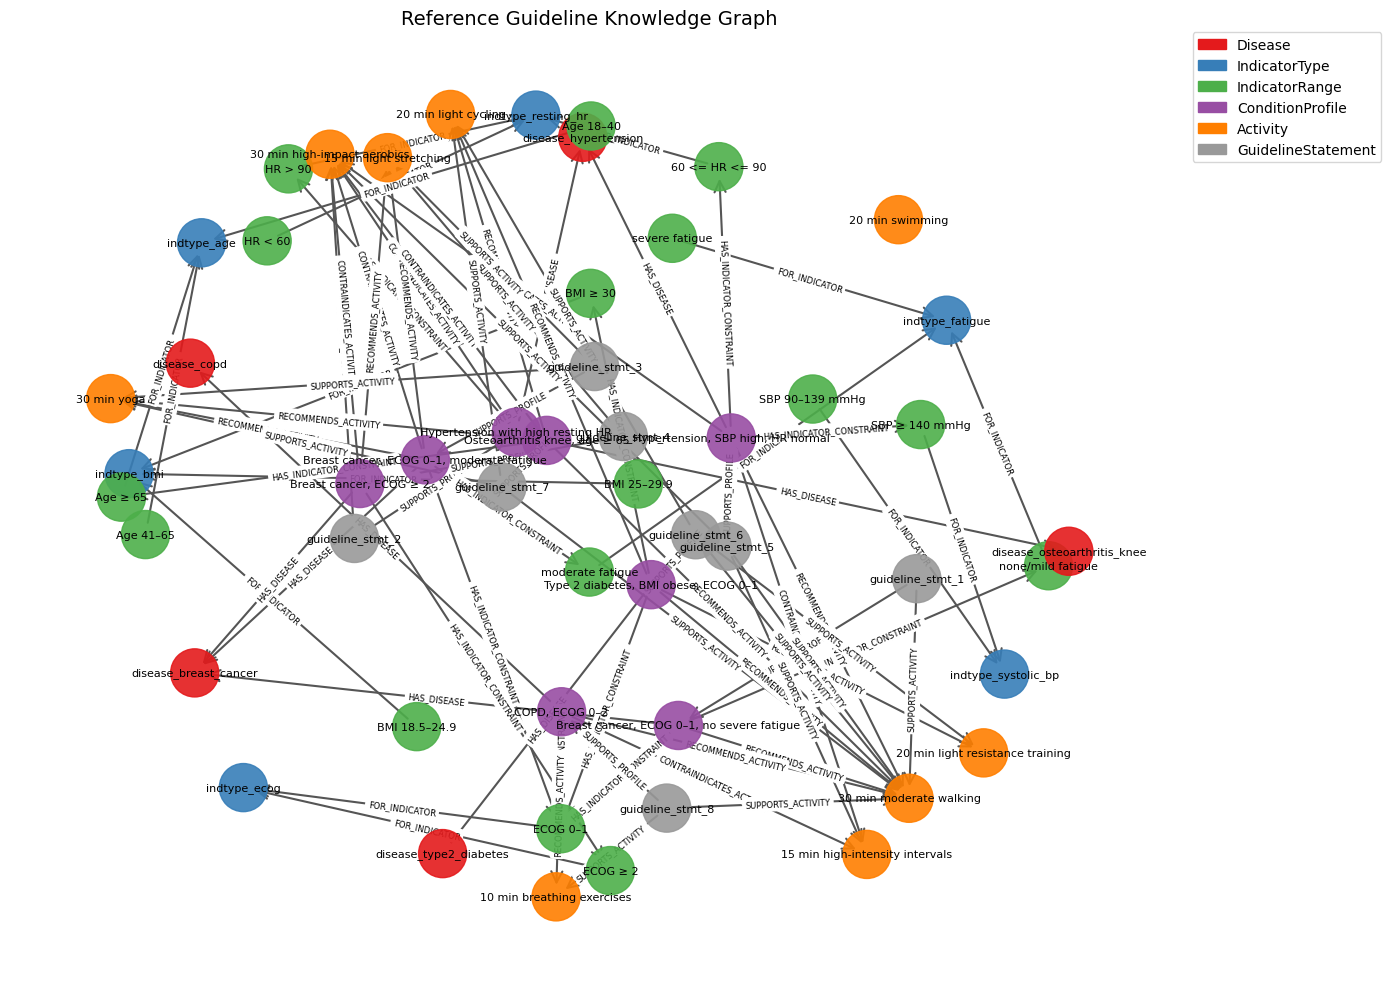

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx


pos = nx.spring_layout(G, k=0.7, seed=42)

node_types = nx.get_node_attributes(G, "type")

type_to_color = {
    "Disease": "#e41a1c",            # red
    "IndicatorType": "#377eb8",      # blue
    "IndicatorRange": "#4daf4a",     # green
    "ConditionProfile": "#984ea3",   # purple
    "Activity": "#ff7f00",           # orange
    "GuidelineStatement": "#999999"  # grey
}


node_colors = [type_to_color.get(node_types[n], "#cccccc") for n in G.nodes()]


labels = {n: G.nodes[n].get("label", n) for n in G.nodes()}

plt.figure(figsize=(14, 10))


nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1200,
    alpha=0.9
)


nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="->",
    arrowsize=20,
    edge_color="#555555",
    width=1.5
)


nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=8
)

edge_labels = nx.get_edge_attributes(G, "type")
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=6
)


legend_patches = []
for t, color in type_to_color.items():
    legend_patches.append(mpatches.Patch(color=color, label=t))

plt.legend(
    handles=legend_patches,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.
)

plt.title("Reference Guideline Knowledge Graph", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()
